In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Gauss
def solve_tridiagonal(a, b, c, d):
    n = len(d)
    cp = np.zeros(n)
    dp = np.zeros(n)

    cp[0] = c[0] / b[0]
    dp[0] = d[0] / b[0]

    for i in range(1, n):
        m = 1.0 / (b[i] - a[i] * cp[i - 1])
        cp[i] = c[i] * m
        dp[i] = (d[i] - a[i] * dp[i - 1]) * m

    x = np.zeros(n)
    x[-1] = dp[-1]

    for i in range(n - 2, -1, -1):
        x[i] = dp[i] - cp[i] * x[i + 1]

    return x

In [4]:
M = 500
eps = 1e-9
Max = 0.0
t_fin = 125
tau = 0.0
L = 0.014
k1 = 2.3
ro1 = 1000
c1 = 2100
k2 = 0.6
ro2 = 1000
c2 = 4200
T2 = 0.1
T1 = -0.5
T = 0.0
lamda = 335000

In [5]:
a1 = k1 / (ro1 * c1)
a2 = k2 / (ro2 * c2)

time = 0.0
h = L / (M - 1)

T_arr = np.full(M + 1, T2)
Tn = np.full(M + 1, T2)
Ts = np.full(M + 1, T2)

times = [25, 50, 75, 100, t_fin]
results = {}
x = h * np.arange(M)
k = 1

\begin{cases}
T_1(s(t), t) = T_m \\
T_2(s(t), t) = T_m \\
k_1 \frac{\partial T_1}{\partial x} - k_2 \frac{\partial T_2}{\partial x} = \rho L \frac{ds}{dt}
\end{cases}

$$
\rho L \frac{ds}{dt} = k_1 \nabla T_1 \cdot \mathbf{n} - k_2 \nabla T_2 \cdot \mathbf{n}
$$

In [6]:
while time < t_fin:
    time_prev = time
    Tn[:] = T_arr[:]
    k += 1
    Max = 0
    stable = False

    while not stable:
        Ts[:] = T_arr[:]
        T_arr[0] = T1
        tau = (a1 * a2 * lamda * (ro1 + ro2) * (h ** 2) - (h ** 2) * (k1 * a2 + k2 * a1) * (T - Tn[k])) / (
                    2 * a1 * a2 * (k1 * (T - T_arr[k - 1]) - k2 * (T_arr[k + 1] - T)))

        n1 = k + 1
        a = np.zeros(n1)
        b = np.zeros(n1)
        c = np.zeros(n1)
        d = np.zeros(n1)
        b[0] = 1
        d[0] = T1

        for i in range(1, k):
            a[i] = -a1 / h ** 2
            b[i] = 2 * a1 / h ** 2 + 1 / abs(tau)
            c[i] = -a1 / h ** 2
            d[i] = Tn[i] / abs(tau)

        a[k] = -k1 / h
        b[k] = k1 / h + k2 / h
        c[k] = -k2 / h
        d[k] = 0

        solution1 = solve_tridiagonal(a, b, c, d)
        T_arr[:k + 1] = solution1

        n2 = M - k + 1
        a = np.zeros(n2)
        b = np.zeros(n2)
        c = np.zeros(n2)
        d = np.zeros(n2)

        b[0] = 1
        d[0] = T_arr[k]

        for i in range(1, n2 - 1):
            a[i] = -a2 / h ** 2
            b[i] = 2 * a2 / h ** 2 + 1 / abs(tau)
            c[i] = -a2 / h ** 2
            d[i] = Tn[k + i] / abs(tau)
        a[-1] = -1 / h
        b[-1] = 1 / h
        c[-1] = 0
        d[-1] = 0

        solution2 = solve_tridiagonal(a, b, c, d)
        T_arr[k:] = solution2

        Max = np.max(np.abs(T_arr[1:] - Ts[1:]))
        if Max <= eps:
            stable = True

    time += abs(tau)
    print(f"time = {time:.5f}, tau = {tau:.5e}")

    for t in times[:]:
        if time_prev < t <= time:
            results[t] = T_arr[1:M + 1].copy()
            times.remove(t)

time = 0.23773, tau = 2.37734e-01
time = 0.51054, tau = 2.72806e-01
time = 0.82192, tau = 3.11382e-01
time = 1.17240, tau = 3.50481e-01
time = 1.56219, tau = 3.89784e-01
time = 1.99138, tau = 4.29193e-01
time = 2.46005, tau = 4.68668e-01
time = 2.96824, tau = 5.08187e-01
time = 3.51597, tau = 5.47736e-01
time = 4.10328, tau = 5.87308e-01
time = 4.73018, tau = 6.26898e-01
time = 5.39668, tau = 6.66501e-01
time = 6.10279, tau = 7.06115e-01
time = 6.84853, tau = 7.45738e-01
time = 7.63390, tau = 7.85368e-01
time = 8.45890, tau = 8.25004e-01
time = 9.32355, tau = 8.64646e-01
time = 10.22784, tau = 9.04291e-01
time = 11.17178, tau = 9.43941e-01
time = 12.15537, tau = 9.83594e-01
time = 13.17862, tau = 1.02325e+00
time = 14.24153, tau = 1.06291e+00
time = 15.34410, tau = 1.10257e+00
time = 16.48633, tau = 1.14223e+00
time = 17.66823, tau = 1.18189e+00
time = 18.88979, tau = 1.22156e+00
time = 20.15102, tau = 1.26123e+00
time = 21.45191, tau = 1.30090e+00
time = 22.79248, tau = 1.34057e+00
ti

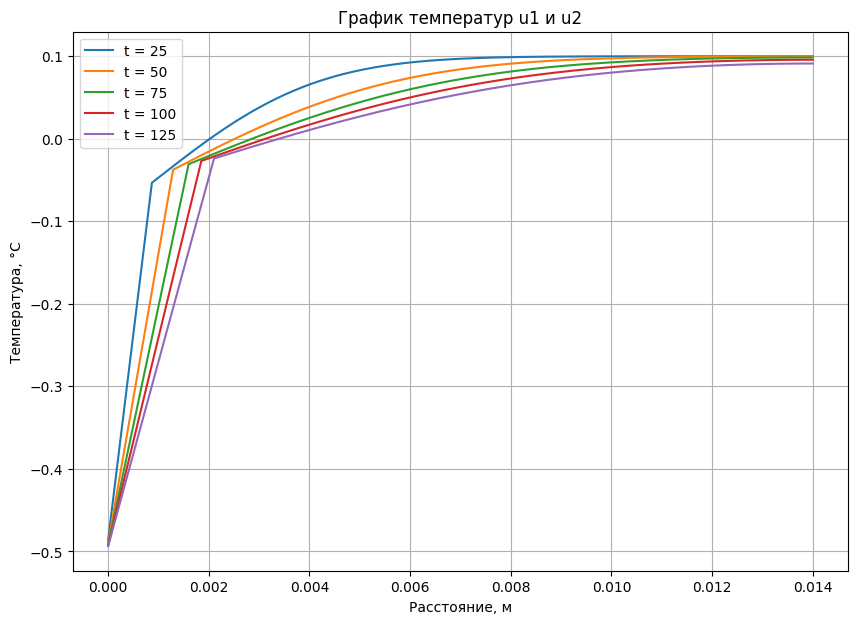

In [11]:
plt.figure(figsize=(10, 7))
for t, temp in results.items():
    plt.plot(x, temp, label=f't = {t}')
    

plt.xlabel('Расстояние, м')
plt.ylabel('Температура, °C')
plt.title('График температур u1 и u2')
plt.grid(True)
plt.legend()
plt.show()